# Distribuzione TITOLO_MISURA per record AI

Analisi della distribuzione delle misure associate ai record identificati come AI, caricando direttamente i dati aggregati completi dal file `ai_records_full_export.csv`.

In [1]:
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'src').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

data_file = REPO_ROOT / 'data' / 'technology_mapping' / 'ai_records_full_export.csv'
print('Caricamento dati da:', data_file)

Caricamento dati da: /home/gabs/Documenti/Università/AI nelle Imprese/open-data-analytics/data/technology_mapping/ai_records_full_export.csv


In [2]:
# Carichiamo il dataset assicurandoci che sia tutto di tipo stringa
df = pd.read_csv(data_file, dtype=str).fillna('')
print(f'Trovati {len(df)} record totali.')

# Filtriamo via le righe senza TITOLO_MISURA (se presenti) per una visualizzazione più pulita
df_plot = df[df['TITOLO_MISURA'].astype(str).str.strip() != '']
print(f'Record con TITOLO_MISURA valido: {len(df_plot)}')

Trovati 7022 record totali.
Record con TITOLO_MISURA valido: 7022


/tmp/ipykernel_76515/3251054193.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top10, y='TITOLO_MISURA', order=top_10, palette='viridis')
/tmp/ipykernel_76515/3251054193.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


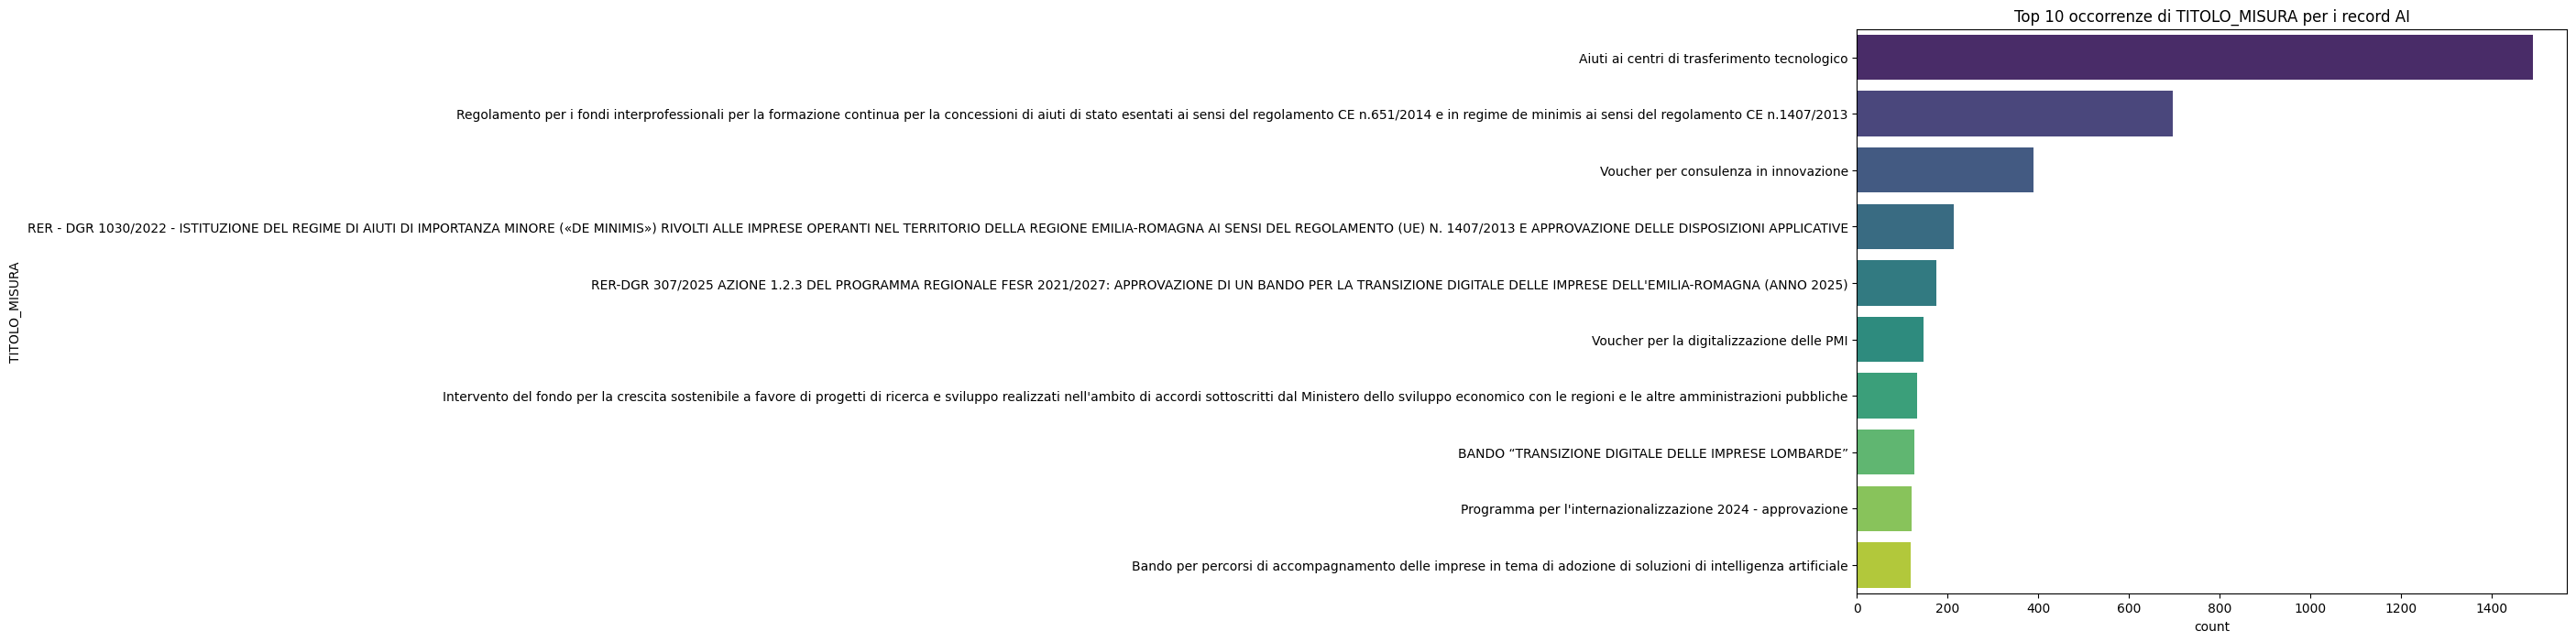

In [3]:
# Filtro per tenere solo le Top 10 misure per frequenza
top_10 = df_plot['TITOLO_MISURA'].value_counts().nlargest(10).index
df_top10 = df_plot[df_plot['TITOLO_MISURA'].isin(top_10)]

# Visualizzazione con seaborn
plt.figure(figsize=(10, 8))
sns.countplot(data=df_top10, y='TITOLO_MISURA', order=top_10, palette='viridis')
plt.title('Top 10 occorrenze di TITOLO_MISURA per i record AI')
plt.tight_layout()
plt.show()